# Preprocessing & Ekstraksi Fitur CO dan SO₂ — Kecamatan Kedungpring


## Import Pustaka

In [1]:
import os
import inspect

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tsfel.feature_extraction.features as tsfel_features

CSV_DIR = "../data/csv/"
FEATURE_DIR = "../data/features/"
os.makedirs(FEATURE_DIR, exist_ok=True)

TEMPORAL_EXTENT = ["2025-08-31", "2026-08-31"]  # sama seperti tahap ekstraksi
POLLUTANTS_TO_PROCESS = ["CO", "SO2"]

raw_csv_paths = {
    band: os.path.join(CSV_DIR, f"{band}-Kedungpring.csv")
    for band in POLLUTANTS_TO_PROCESS
}

for band, path in raw_csv_paths.items():
    exists = os.path.exists(path)
    print(f"[{band}] {path} {'ditemukan' if exists else 'TIDAK DITEMUKAN'}")

[CO] ../data/csv/CO-Kedungpring.csv ditemukan
[SO2] ../data/csv/SO2-Kedungpring.csv ditemukan


---
# Preprocessing (Loop CO & SO₂)

## 1. Reindex ke Deret Harian Penuh

Data mentah hanya berisi baris untuk hari-hari dengan observasi satelit valid. Setiap
polutan di-**reindex** ke deret tanggal harian penuh (31 Agustus 2025 – 31 Agustus
2026, 366 hari) — hari yang sebelumnya "tidak ada barisnya" menjadi eksplisit `NaN`,
siap ditangani pada tahap imputasi.

## 2. Deteksi Outlier — Metode IQR

$$IQR = Q_3 - Q_1$$
$$\text{Batas Bawah} = Q_1 - 1.5 \times IQR \qquad \text{Batas Atas} = Q_3 + 1.5 \times IQR$$

Titik data $x_i$ dikategorikan **outlier** apabila $x_i < \text{Batas Bawah}$ atau
$x_i > \text{Batas Atas}$. Outlier ditandai sebagai NaN (bukan dihapus barisnya), agar
struktur deret waktu harian tetap utuh.

## 3. Imputasi hingga 0 NaN

Missing value (dari reindex) dan outlier (dari IQR) diisi bersamaan menggunakan
interpolasi linear berbasis waktu, dilanjutkan forward/backward fill. Sebuah `assert`
memastikan hasil akhir **benar-benar 0 NaN** sebelum lanjut ke ekstraksi fitur.

In [2]:
def preprocess_pollutant(csv_path, band, temporal_extent, csv_dir):
    """Reindex -> deteksi outlier (IQR) -> imputasi hingga 0 NaN. Mengembalikan df bersih."""
    df_raw = pd.read_csv(csv_path)
    df_raw["date"] = pd.to_datetime(df_raw["date"])
    df_raw[band] = pd.to_numeric(df_raw[band], errors="coerce")

    print(f"[{band}] Jumlah baris SEBELUM reindex: {len(df_raw)}")

    full_date_range = pd.date_range(start=temporal_extent[0], end=temporal_extent[1], freq="D")
    df = (
        df_raw.set_index("date")
        .reindex(full_date_range)
        .rename_axis("date")
        .reset_index()
    )
    print(f"[{band}] Jumlah baris SETELAH reindex: {len(df)}")
    print(f"[{band}] Missing value setelah reindex: {df[band].isna().sum()}")

    valid_values = df[band].dropna()
    Q1 = valid_values.quantile(0.25)
    Q3 = valid_values.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    is_outlier = (df[band] < lower_bound) | (df[band] > upper_bound)
    print(f"[{band}] Outlier terdeteksi: {is_outlier.sum()} dari {valid_values.shape[0]} data valid")

    df_before_impute = df.copy()
    df_before_impute["is_outlier"] = is_outlier
    df.loc[is_outlier, band] = np.nan

    df_clean = df.set_index("date").interpolate(method="time").ffill().bfill()
    n_missing_after = df_clean[band].isna().sum()
    assert n_missing_after == 0, f"[{band}] Masih ada NaN tersisa setelah imputasi!"
    print(f"[{band}] ✅ Bersih — 0 NaN, 0 outlier tersisa.")

    df_clean = df_clean.reset_index()
    clean_csv_path = os.path.join(csv_dir, f"{band}-Kedungpring-clean.csv")
    df_clean.to_csv(clean_csv_path, index=False)
    print(f"[{band}] Data bersih disimpan: {clean_csv_path}\n")

    return df_before_impute, df_clean

In [3]:
clean_data = {}
before_impute_data = {}

for band in POLLUTANTS_TO_PROCESS:
    if not os.path.exists(raw_csv_paths[band]):
        print(f"[{band}] Dilewati — file mentah tidak ditemukan: {raw_csv_paths[band]}")
        continue
    df_before, df_clean = preprocess_pollutant(
        raw_csv_paths[band], band, TEMPORAL_EXTENT, CSV_DIR
    )
    before_impute_data[band] = df_before
    clean_data[band] = df_clean

[CO] Jumlah baris SEBELUM reindex: 205
[CO] Jumlah baris SETELAH reindex: 366
[CO] Missing value setelah reindex: 161
[CO] Outlier terdeteksi: 1 dari 205 data valid
[CO] ✅ Bersih — 0 NaN, 0 outlier tersisa.
[CO] Data bersih disimpan: ../data/csv/CO-Kedungpring-clean.csv

[SO2] Jumlah baris SEBELUM reindex: 221
[SO2] Jumlah baris SETELAH reindex: 366
[SO2] Missing value setelah reindex: 145
[SO2] Outlier terdeteksi: 12 dari 221 data valid
[SO2] ✅ Bersih — 0 NaN, 0 outlier tersisa.
[SO2] Data bersih disimpan: ../data/csv/SO2-Kedungpring-clean.csv



## Visualisasi: Outlier & Deret Waktu Bersih (CO dan SO₂)

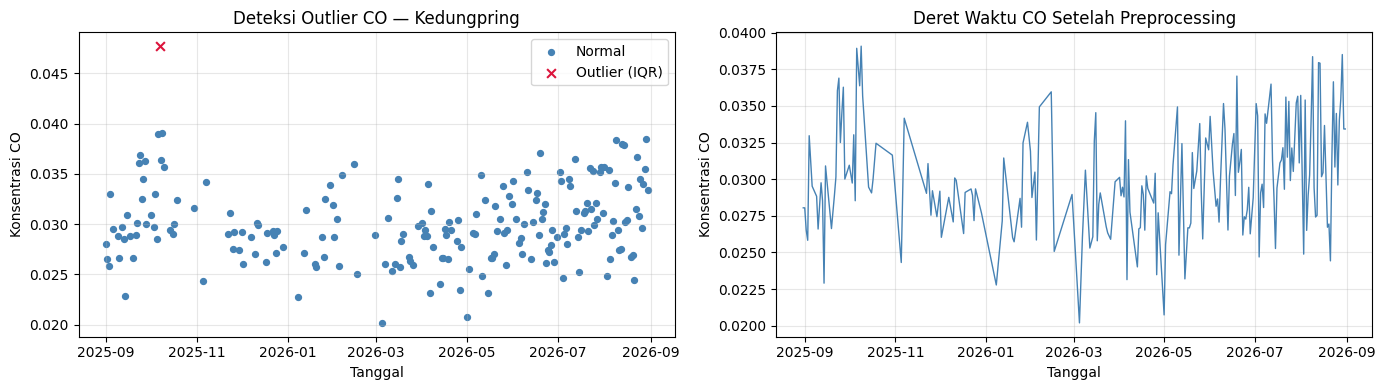

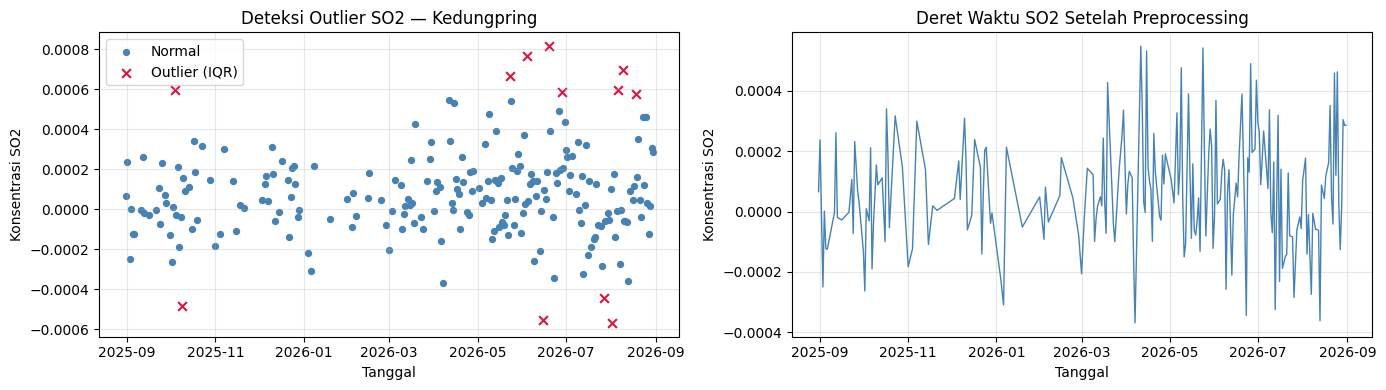

In [4]:
for band in POLLUTANTS_TO_PROCESS:
    if band not in clean_data:
        continue

    df_before = before_impute_data[band]
    df_clean = clean_data[band]

    normal = df_before[~df_before["is_outlier"]]
    outliers = df_before[df_before["is_outlier"]]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].scatter(normal["date"], normal[band], color="steelblue", s=18, label="Normal")
    axes[0].scatter(outliers["date"], outliers[band], color="crimson", s=40, marker="x", label="Outlier (IQR)")
    axes[0].set_title(f"Deteksi Outlier {band} — Kedungpring")
    axes[0].set_xlabel("Tanggal")
    axes[0].set_ylabel(f"Konsentrasi {band}")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(df_clean["date"], df_clean[band], color="steelblue", linewidth=1)
    axes[1].set_title(f"Deret Waktu {band} Setelah Preprocessing")
    axes[1].set_xlabel("Tanggal")
    axes[1].set_ylabel(f"Konsentrasi {band}")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

---
# Ekstraksi 68 Fitur dengan TSFEL (Loop CO & SO₂)

Fitur diekstrak dari **68 fungsi** di `tsfel.feature_extraction.features`, mencakup
domain **statistical**, **temporal**, dan **spectral**. Penjelasan lengkap tiap fitur
(rumus, contoh perhitungan) sudah dibahas rinci pada notebook preprocessing NO₂
sebelumnya — di sini kode ekstraksinya dijalankan sebagai fungsi yang sama, di-loop
untuk CO dan SO₂.

In [5]:
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print("Jumlah fitur yang akan diekstrak per polutan:", len(FEATURE_LIST))


def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)


def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)


def extract_tsfel_features(signal_1d, band, feature_dir):
    fs = 1
    row = {}
    for fn_name in FEATURE_LIST:
        try:
            row[fn_name] = extract_one(fn_name, signal_1d, fs)
        except Exception as e:
            print(f"[{band}] [PERINGATAN] Gagal mengekstrak fitur '{fn_name}': {e}")
            row[fn_name] = np.nan

    features_df = pd.DataFrame([row])
    feature_csv_path = os.path.join(feature_dir, f"{band}_Kedungpring_TSFEL.csv")
    features_df.to_csv(feature_csv_path, index=False)
    print(f"[{band}] Fitur tersimpan: {feature_csv_path} ({features_df.shape[1]} fitur)")
    return features_df

Jumlah fitur yang akan diekstrak per polutan: 68


In [6]:
feature_results = {}

for band in POLLUTANTS_TO_PROCESS:
    if band not in clean_data:
        continue
    signal_1d = clean_data[band][band].astype(float).values
    feature_results[band] = extract_tsfel_features(signal_1d, band, FEATURE_DIR)

print("\nRingkasan fitur yang berhasil diekstrak:")
for band, feats in feature_results.items():
    print(f" - {band}: {feats.shape[1]} fitur -> {FEATURE_DIR}{band}_Kedungpring_TSFEL.csv")

[CO] Fitur tersimpan: ../data/features/CO_Kedungpring_TSFEL.csv (68 fitur)
[SO2] Fitur tersimpan: ../data/features/SO2_Kedungpring_TSFEL.csv (68 fitur)

Ringkasan fitur yang berhasil diekstrak:
 - CO: 68 fitur -> ../data/features/CO_Kedungpring_TSFEL.csv
 - SO2: 68 fitur -> ../data/features/SO2_Kedungpring_TSFEL.csv
